#  EDA: Análise Exploratória do Funil de Vendas Olist

**Objetivo:** Investigar o dataset mestre da Olist para identificar gargalos, ineficiências e padrões no ciclo de vida dos pedidos. As conclusões desta análise servirão de base para a construção do dashboard final e para as recomendações de negócio.

**Estrutura da Análise:**
1.  **Configuração Inicial:** Carregamento das bibliotecas e do dataset processado.
2.  **Análise de Cancelamentos:** Investigar os principais motivos e perfis de pedidos cancelados.
3.  **Análise do Funil Operacional e Outliers:** Mapear o tempo gasto em cada etapa e entender os impactos dos outliers.
4.  **Análise de Performance de Entrega:** Avaliar a pontualidade e os fatores que impactam atrasos.
5.  **Análise Geográfica:** Entender o impacto da localização na logística.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = '/home/portugal/Documentos/Projects/GitHub/AnaliseFunilDeVendas/data/'

In [2]:
sns.set_style('whitegrid')
plt.style.use('ggplot')

def valores_acima_barra():
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, color='black', xytext=(0,5), textcoords='offset points')
    return 
    


In [3]:
try:
    processed_path = os.path.join('..', 'data', 'processed', 'olist_master_dataset.parquet')
    df = pd.read_parquet(processed_path)
    print("Dataset mestre carregado com sucesso!")
    print(f"Shape do DataFrame: {df.shape}")
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{processed_path}'. Certifique-se de que o pipeline de ETL foi executado.")


Dataset mestre carregado com sucesso!
Shape do DataFrame: (119143, 43)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   order_item_id                  118310 non-null  float64       
 9   product_id                     118310 non-null  object        
 10  seller_id                      118310 non-null  object        
 11  

### Análise de Cancelamentos

* Qual é o perfil dos pedidos cancelados? 
* Qual o total de cancelamento?
* Qual a porcentagem de cancelamento ?
* Existem padrões relacionados à localização do cliente ou ao método de pagamento?

In [5]:
df_canceled = df[df['order_status'] == 'canceled'].copy()

print(f'Total de pedidos cancelados: {len(df_canceled)}')
print(f'Porcentagem de pedidos cancelados: {len(df_canceled) / len(df) * 100:.2f}% ')

# plt.figure(figsize=(10,6))

# plt.title('Cancelamento %', loc='left', pad=10)


Total de pedidos cancelados: 750
Porcentagem de pedidos cancelados: 0.63% 


# Cancelamentos Por Estado

/tmp/ipykernel_6900/1452605812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_canceled_states.index, y=top_10_canceled_states.values, palette='viridis')


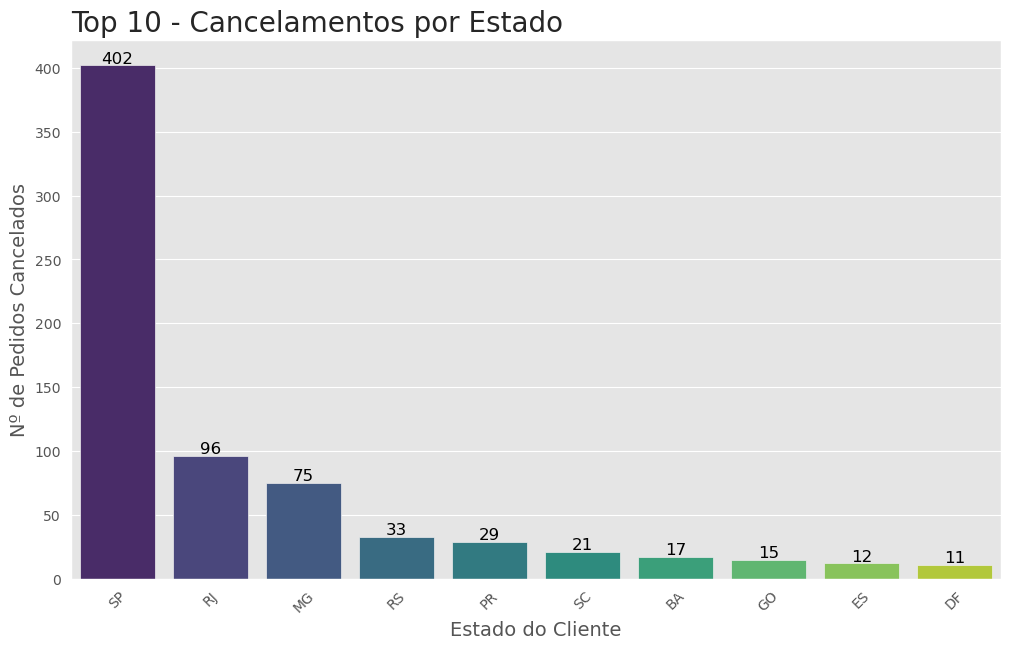

In [6]:
top_10_canceled_states = df_canceled['customer_state'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(x=top_10_canceled_states.index, y=top_10_canceled_states.values, palette='viridis')
# ax = sns.barplot(hue=top_10_canceled_states.index, y=top_10_canceled_states.values, legend=True)

plt.title('Top 10 - Cancelamentos por Estado', loc='left', fontsize=20)

plt.xlabel('Estado do Cliente', fontsize=14)
plt.xticks(rotation=45)

plt.ylabel('Nº de Pedidos Cancelados', fontsize=14)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, color='black', xytext=(0,5), textcoords='offset points')

**Insight:** O estado de São Paulo (SP) lidera disparadamente o número de cancelamentos, seguido pelo Rio de Janeiro (RJ) e Minas Gerais (MG). Embora isso seja esperado, já que são os maiores mercados, a proporção pode indicar problemas específicos nessas regiões.


/tmp/ipykernel_6900/4196170634.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=canceled_by_payment.index, y=canceled_by_payment.values, palette='mako', legend=True)


Text(1.0, 1.0, 'Cancelamento por Metodo de Pagamento')

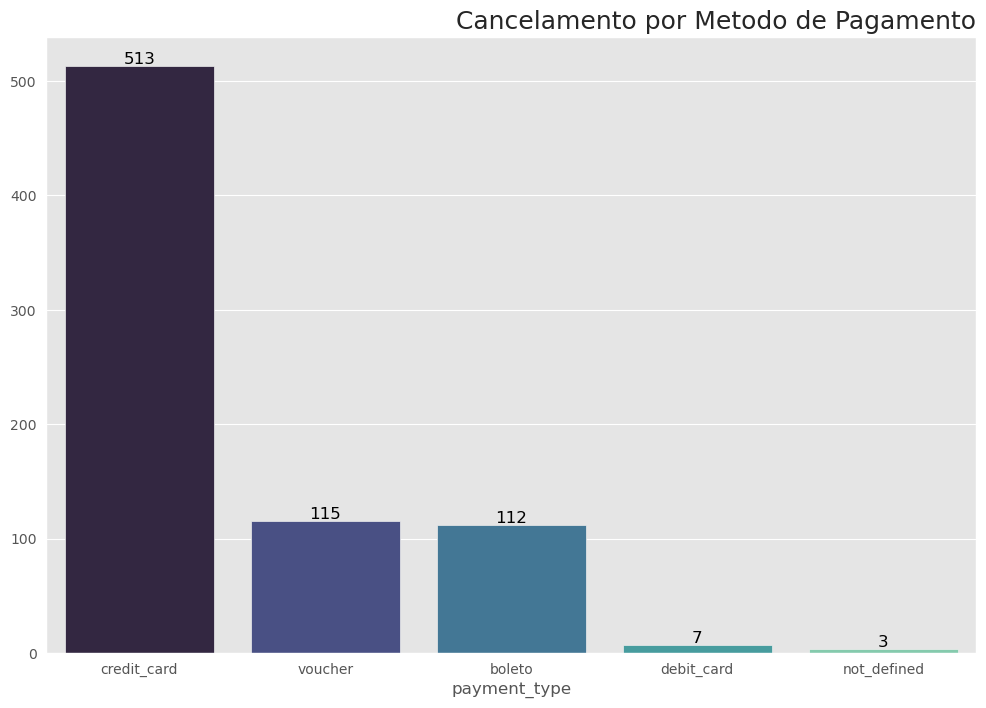

In [7]:
canceled_by_payment = df_canceled['payment_type'].value_counts()

plt.figure(figsize=(12,8))
ax = sns.barplot(x=canceled_by_payment.index, y=canceled_by_payment.values, palette='mako', legend=True)
valores_acima_barra()

plt.title('Cancelamento por Metodo de Pagamento', loc='right', fontsize=18)



**Insight:** A maioria esmagadora dos cancelamentos ocorre em pedidos feitos com cartão de crédito, seguido por boleto. O fato de "cartão de crédito" ser o líder pode ser contraintuitivo e merece uma investigação mais profunda. Possíveis causas:

1.  **Falha na aprovação pela operadora:** O pedido é criado, mas o pagamento é recusado.
2.  **Fraude:** Detecção de fraude que leva ao cancelamento.
3.  **Arrependimento rápido:** O cliente compra por impulso e cancela logo em seguida.

# Cancelamentos por Estado

Com essa query os dados de cancelamento de **SP, RJ, MG** chamam atenção

<Axes: title={'left': 'Cancelamentos de Pedido'}, xlabel='order_status', ylabel='count'>

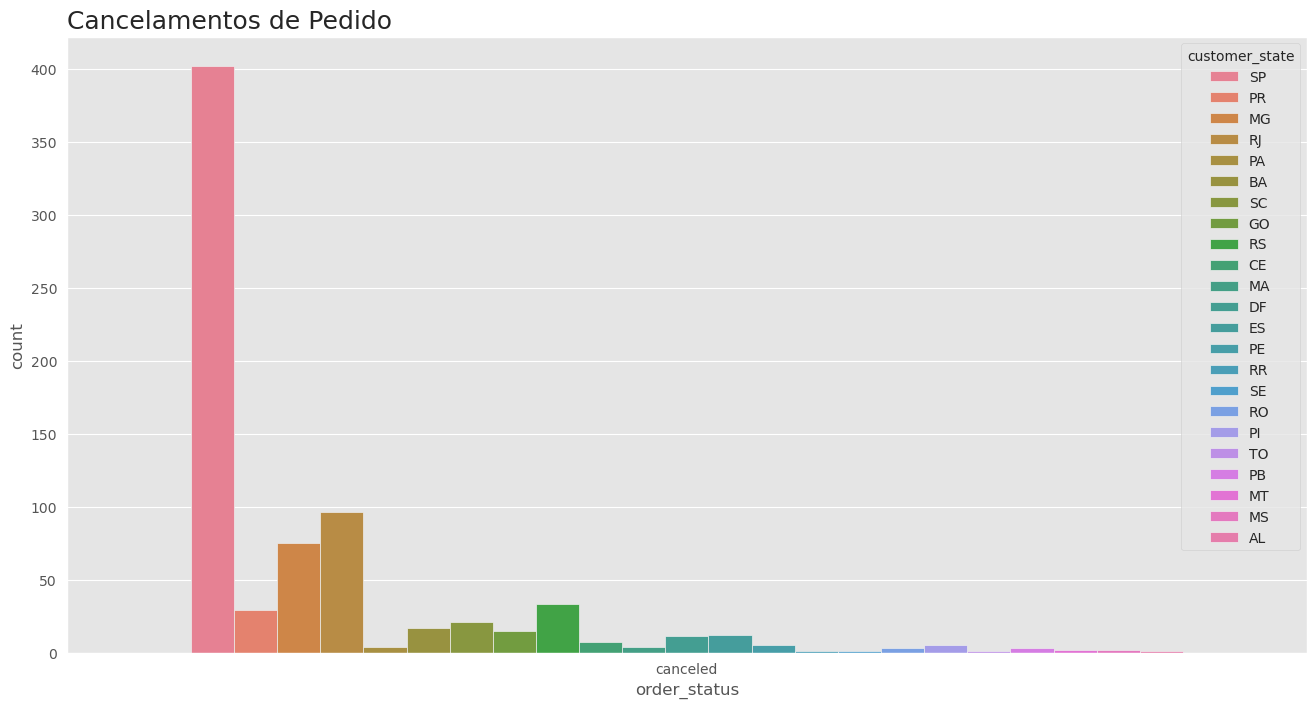

In [8]:
plt.style.use('ggplot')

plt.figure(figsize=(16,8))

plt.title('Cancelamentos de Pedido', loc='left',fontsize=18)
"""  """
sns.countplot(data=df_canceled, x=df_canceled['order_status'], hue='customer_state')

### 3. Análise do Funil Operacional

**Pergunta de Negócio:** Quanto tempo, em média, um pedido leva em cada etapa do nosso processo interno (aprovação, despacho)? Onde estão os maiores "delays"?

**Metodologia:** Vamos calcular a diferença (delta) entre os timestamps de cada etapa para criar novas colunas de duração. Depois, analisaremos a distribuição desses tempos.

In [9]:
df['tempo_aprovacao'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / (60*60*24)
df['tempo_despacho_vendedor'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds()  / (60*60*24)
df['tempo_entrega_transportadora'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds() / (60*60*24)
df['tempo_total_entrega'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (60*60*24)

# Calculando a diferença em relação à estimativa
df['diferenca_estimativa'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.total_seconds() / (60*60*24)


In [10]:
# Descrevendo as estatísticas das novas colunas de tempo
metricas_tempo = ['tempo_aprovacao', 'tempo_despacho_vendedor', 'tempo_entrega_transportadora', 'tempo_total_entrega', 'diferenca_estimativa']
print("Estatísticas Descritivas dos Tempos do Funil (em dias):")
df[metricas_tempo].describe().transpose()

Estatísticas Descritivas dos Tempos do Funil (em dias):


,count,mean,std,min,25%,50%,75%,max
tempo_aprovacao,118966.0,0.440876,1.081500,0.000000,0.008981,0.014456,0.627025,187.882523
tempo_despacho_vendedor,117042.0,2.856355,3.591558,-171.219005,0.887216,1.848345,3.650347,125.762569
tempo_entrega_transportadora,115721.0,9.201678,8.634634,-16.096169,4.063935,7.062431,11.929850,205.190972
tempo_total_entrega,115722.0,12.488071,9.448970,0.533414,6.753177,10.202112,15.556623,209.628611
diferenca_estimativa,115722.0,11.351790,10.166040,-188.975081,6.507159,12.056476,16.315833,146.016123


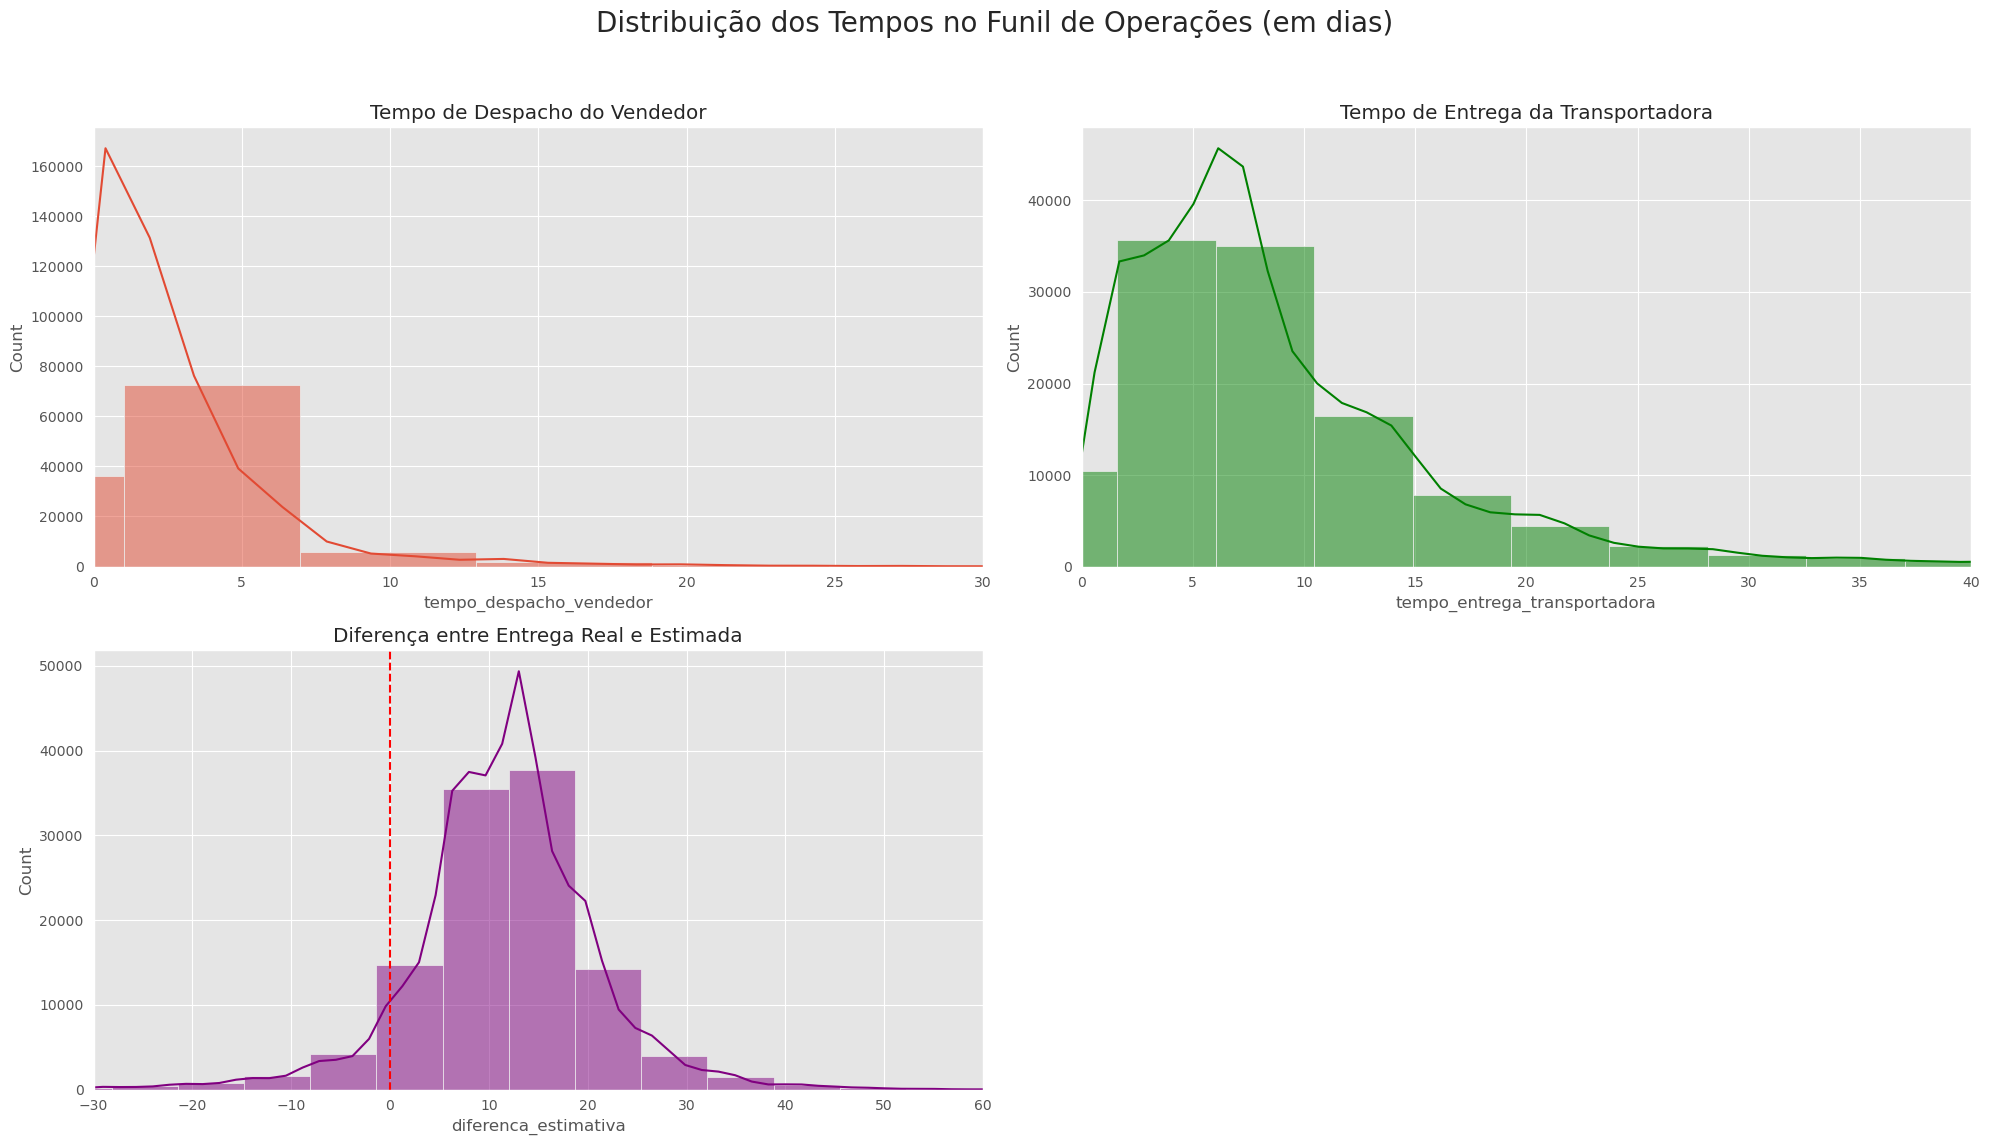

In [11]:

# Visualizando a distribuição dos tempos
plt.figure(figsize=(20, 12))
plt.suptitle('Distribuição dos Tempos no Funil de Operações (em dias)', fontsize=20)

# Gráfico 1: Tempo de Despacho pelo Vendedor
plt.subplot(2, 2, 1)
sns.histplot(df['tempo_despacho_vendedor'].dropna(), kde=True, bins=50)
plt.title('Tempo de Despacho do Vendedor')
plt.xlim(0, 30) # Limitando o eixo x para melhor visualização

# Gráfico 2: Tempo de Entrega pela Transportadora
plt.subplot(2, 2, 2)
sns.histplot(df['tempo_entrega_transportadora'].dropna(), kde=True, bins=50, color='green')
plt.title('Tempo de Entrega da Transportadora')
plt.xlim(0, 40)

# Gráfico 3: Diferença para a Estimativa
plt.subplot(2, 2, 3)
sns.histplot(df['diferenca_estimativa'].dropna(), kde=True, bins=50, color='purple')
plt.title('Diferença entre Entrega Real e Estimada')
plt.axvline(0, color='red', linestyle='--') # Linha para marcar o ponto de atraso
plt.xlim(-30, 60)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


/tmp/ipykernel_6900/1112105294.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='tempo_despacho_vendedor', width=0.35, palette='husl')
/tmp/ipykernel_6900/1112105294.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='tempo_entrega_transportadora', width=0.35, palette='husl')


<Axes: title={'center': 'Tempo Entrega Transportadora'}, ylabel='tempo_entrega_transportadora'>

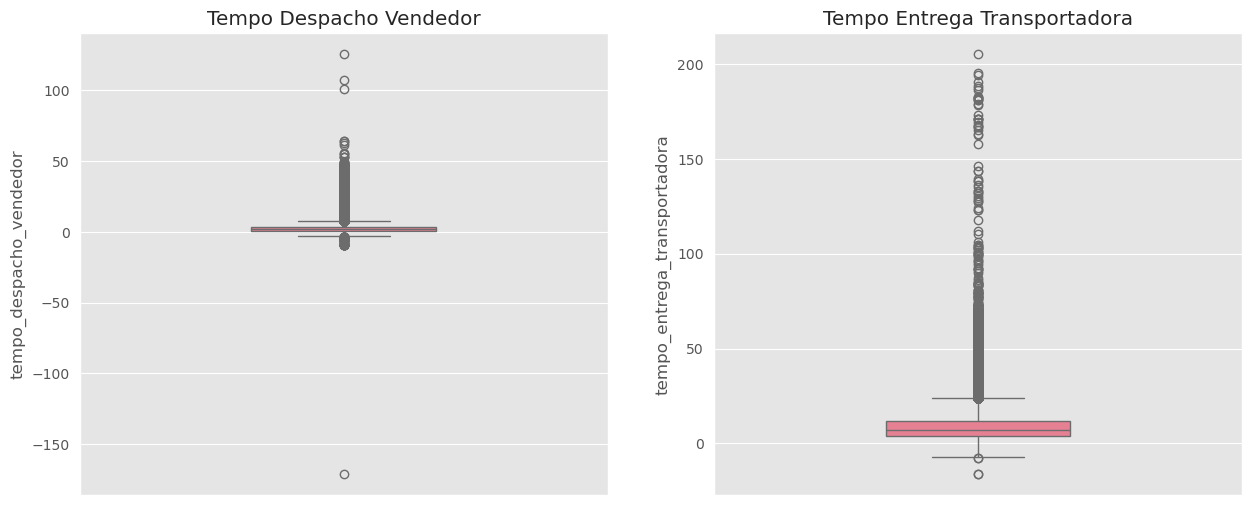

In [12]:
# Figure
plt.figure(figsize=(15,6))


# Grid 1
plt.subplot(1, 2, 1)
# Plot
plt.title('Tempo Despacho Vendedor')
sns.boxplot(data=df, y='tempo_despacho_vendedor', width=0.35, palette='husl')

# Grid 2
plt.subplot(1, 2, 2)
# Plot
plt.title('Tempo Entrega Transportadora')
sns.boxplot(data=df, y='tempo_entrega_transportadora', width=0.35, palette='husl')


### Análise de Outliers para 'tempo_aprovacao'

In [13]:
# Remover os valores NaN ( NumPy não consegue fazer o cálculo com valores NaN )
tempo_despacho_sem_na = df['tempo_aprovacao'].dropna()

# Calculando Q1, Q3 e IQR
Q1 = tempo_despacho_sem_na.quantile(0.25)
Q3 = tempo_despacho_sem_na.quantile(0.75)
IQR = Q3 - Q1

# Definindo os limites para detecção de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Análise de Outliers para 'tempo_aprovacao':")
print(f"Primeiro Quartil (Q1): {Q1:.2f} dias")
print(f"Terceiro Quartil (Q3): {Q3:.2f} dias")
print(f"Intervalo Interquartil (IQR): {IQR:.2f} dias")
print(f"Limite Inferior para Outliers: {limite_inferior:.2f} dias")
print(f"Limite Superior para Outliers: {limite_superior:.2f} dias")

Análise de Outliers para 'tempo_aprovacao':
Primeiro Quartil (Q1): 0.01 dias
Terceiro Quartil (Q3): 0.63 dias
Intervalo Interquartil (IQR): 0.62 dias
Limite Inferior para Outliers: -0.92 dias
Limite Superior para Outliers: 1.55 dias


### Análise de Outliers para 'tempo_entrega_transportadora'

In [14]:
# Remover os valores NaN ( NumPy não consegue fazer o cálculo com valores NaN )
tempo_despacho_sem_na = df['tempo_entrega_transportadora'].dropna()

# Calculando Q1, Q3 e IQR
Q1 = tempo_despacho_sem_na.quantile(0.25)
Q3 = tempo_despacho_sem_na.quantile(0.75)
IQR = Q3 - Q1

# Definindo os limites para detecção de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Análise de Outliers para 'tempo_entrega_transportadora':")
print(f"Primeiro Quartil (Q1): {Q1:.2f} dias")
print(f"Terceiro Quartil (Q3): {Q3:.2f} dias")
print(f"Intervalo Interquartil (IQR): {IQR:.2f} dias")
print(f"Limite Inferior para Outliers: {limite_inferior:.2f} dias")
print(f"Limite Superior para Outliers: {limite_superior:.2f} dias")

Análise de Outliers para 'tempo_entrega_transportadora':
Primeiro Quartil (Q1): 4.06 dias
Terceiro Quartil (Q3): 11.93 dias
Intervalo Interquartil (IQR): 7.87 dias
Limite Inferior para Outliers: -7.73 dias
Limite Superior para Outliers: 23.73 dias


### Análise de Outliers para 'df_tempo_total_entrega'

In [15]:
# Remover os valores NaN ( NumPy não consegue fazer o cálculo com valores NaN )
tempo_despacho_sem_na = df['tempo_total_entrega'].dropna()

# Calculando Q1, Q3 e IQR
Q1 = tempo_despacho_sem_na.quantile(0.25)
Q3 = tempo_despacho_sem_na.quantile(0.75)
IQR = Q3 - Q1

# Definindo os limites para detecção de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Análise de Outliers para 'df_tempo_total_entrega':")
print(f"Primeiro Quartil (Q1): {Q1:.2f} dias")
print(f"Terceiro Quartil (Q3): {Q3:.2f} dias")
print(f"Intervalo Interquartil (IQR): {IQR:.2f} dias")
print(f"Limite Inferior para Outliers: {limite_inferior:.2f} dias")
print(f"Limite Superior para Outliers: {limite_superior:.2f} dias")

Análise de Outliers para 'df_tempo_total_entrega':
Primeiro Quartil (Q1): 6.75 dias
Terceiro Quartil (Q3): 15.56 dias
Intervalo Interquartil (IQR): 8.80 dias
Limite Inferior para Outliers: -6.45 dias
Limite Superior para Outliers: 28.76 dias


### Análise de Outliers para 'tempo_despacho_vendedor'

In [16]:
# Remover os valores NaN ( NumPy não consegue fazer o cálculo com valores NaN )
tempo_despacho_sem_na = df['tempo_despacho_vendedor'].dropna()

# Calculando Q1, Q3 e IQR
Q1 = tempo_despacho_sem_na.quantile(0.25)
Q3 = tempo_despacho_sem_na.quantile(0.75)
IQR = Q3 - Q1

# Definindo os limites para detecção de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Análise de Outliers para 'tempo_despacho_vendedor':")
print(f"Primeiro Quartil (Q1): {Q1:.2f} dias")
print(f"Terceiro Quartil (Q3): {Q3:.2f} dias")
print(f"Intervalo Interquartil (IQR): {IQR:.2f} dias")
print(f"Limite Inferior para Outliers: {limite_inferior:.2f} dias")
print(f"Limite Superior para Outliers: {limite_superior:.2f} dias")

Análise de Outliers para 'tempo_despacho_vendedor':
Primeiro Quartil (Q1): 0.89 dias
Terceiro Quartil (Q3): 3.65 dias
Intervalo Interquartil (IQR): 2.76 dias
Limite Inferior para Outliers: -3.26 dias
Limite Superior para Outliers: 7.80 dias


### Data Frame Filtrado

In [17]:
# Filtrando o DataFrame para remover os outliers
df_sem_outliers = df[(df['tempo_despacho_vendedor'] >= limite_inferior) & 
                    (df['tempo_despacho_vendedor'] <= limite_superior)]

print(f"Tamanho original do DataFrame: {len(df)}")
print(f"Tamanho do DataFrame sem outliers de despacho: {len(df_sem_outliers)}")
print(f"Número de outliers removidos: {len(df) - len(df_sem_outliers)}")


Tamanho original do DataFrame: 119143
Tamanho do DataFrame sem outliers de despacho: 110225
Número de outliers removidos: 8918


 #### Visualizando o Impacto da Remoção de Outliers
 
 **Análise:** Agora vamos plotar o mesmo histograma de antes, mas usando o DataFrame filtrado. Isso nos dará uma visão muito mais clara da performance "típica" dos vendedores.


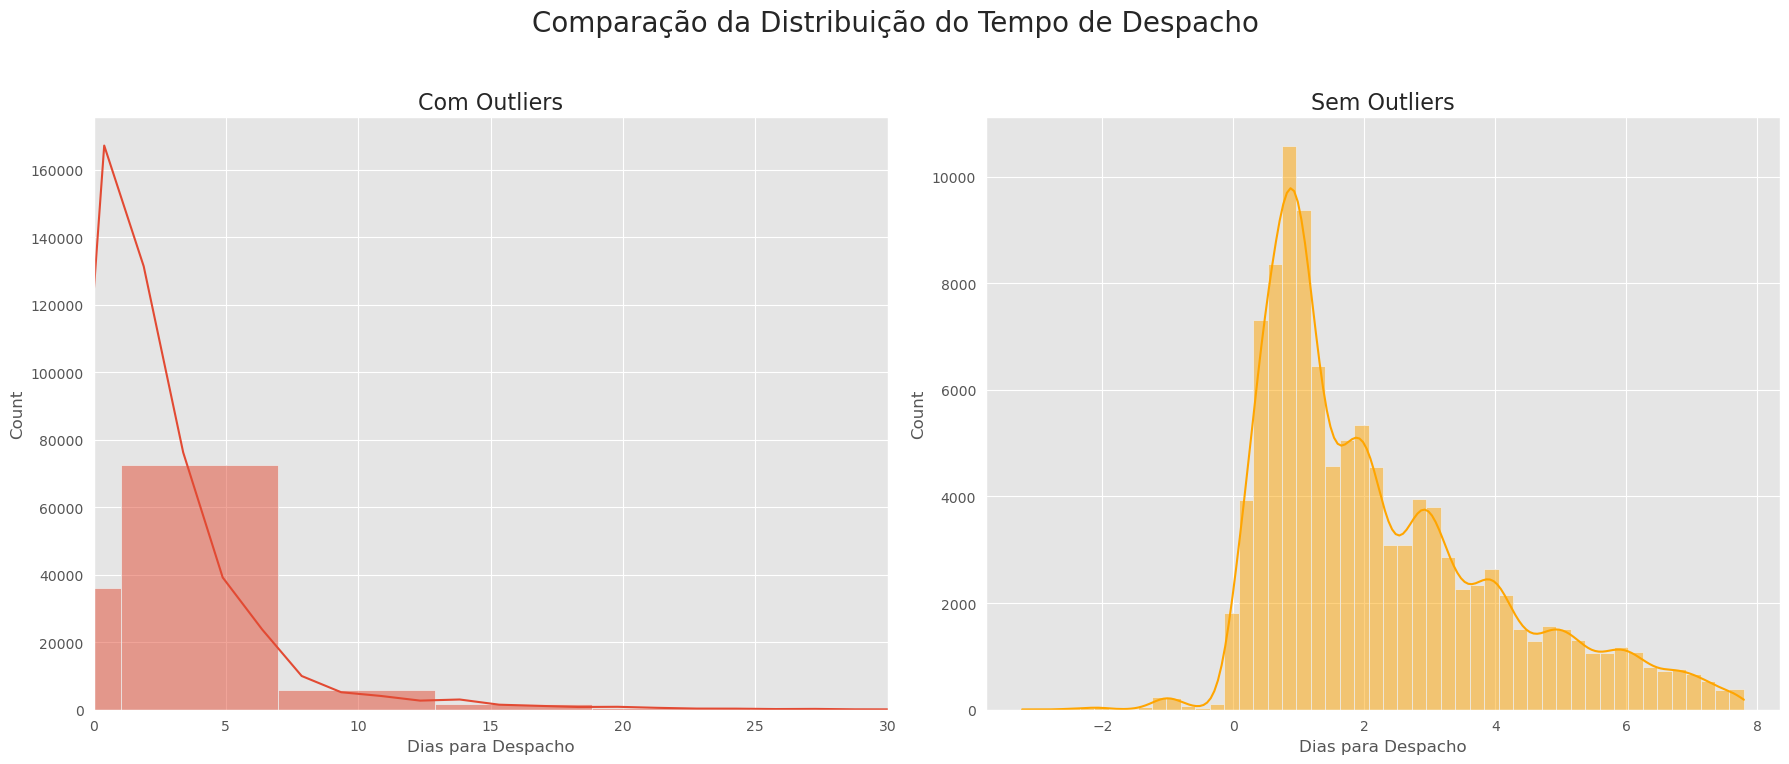

In [18]:
# Comparando as distribuições com e sem outliers
plt.figure(figsize=(18, 8))
plt.suptitle('Comparação da Distribuição do Tempo de Despacho', fontsize=20)

# Gráfico 1: Com Outliers
plt.subplot(1, 2, 1)
sns.histplot(df['tempo_despacho_vendedor'].dropna(), kde=True, bins=50)
plt.title('Com Outliers', fontsize=16)
plt.xlabel('Dias para Despacho')
plt.xlim(0, 30) # Mantendo o mesmo limite para comparação

# Gráfico 2: Sem Outliers
plt.subplot(1, 2, 2)
sns.histplot(df_sem_outliers['tempo_despacho_vendedor'].dropna(), kde=True, bins=50, color='orange')
plt.title('Sem Outliers', fontsize=16)
plt.xlabel('Dias para Despacho')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Remoção dos outliers

### Média de tempo sem outliers

In [19]:
def get_outlier_bounds(series):
    """Calcula os limites inferior e superior para detecção de outliers usando o método IQR."""
    series_sem_na = series.dropna()
    Q1 = series_sem_na.quantile(0.25)
    Q3 = series_sem_na.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

# Dicionário para armazenar os limites de cada métrica
limites_outliers = {}
for col in metricas_tempo:
    limites_outliers[col] = get_outlier_bounds(df[col])
    print(f"Limites para '{col}': Inferior={limites_outliers[col][0]:.2f}, Superior={limites_outliers[col][1]:.2f}")

# %%
# Criando os DataFrames filtrados
df_sem_outliers_despacho = df[(df['tempo_despacho_vendedor'] >= limites_outliers['tempo_despacho_vendedor'][0]) & 
                            (df['tempo_despacho_vendedor'] <= limites_outliers['tempo_despacho_vendedor'][1])]

df_sem_outliers_entrega = df[(df['tempo_entrega_transportadora'] >= limites_outliers['tempo_entrega_transportadora'][0]) & 
                            (df['tempo_entrega_transportadora'] <= limites_outliers['tempo_entrega_transportadora'][1])]

df_sem_outliers_estimativa = df[(df['diferenca_estimativa'] >= limites_outliers['diferenca_estimativa'][0]) & 
                                (df['diferenca_estimativa'] <= limites_outliers['diferenca_estimativa'][1])]



Limites para 'tempo_aprovacao': Inferior=-0.92, Superior=1.55
Limites para 'tempo_despacho_vendedor': Inferior=-3.26, Superior=7.80
Limites para 'tempo_entrega_transportadora': Inferior=-7.73, Superior=23.73
Limites para 'tempo_total_entrega': Inferior=-6.45, Superior=28.76
Limites para 'diferenca_estimativa': Inferior=-8.21, Superior=31.03


#### Visualizando o Impacto da Remoção de Outliers

**Análise:** Os gráficos abaixo mostram o "antes e depois" para as três principais métricas de tempo. A coluna da esquerda mostra a distribuição original, e a da direita mostra a distribuição após a remoção dos outliers, permitindo uma visão mais clara do comportamento padrão.


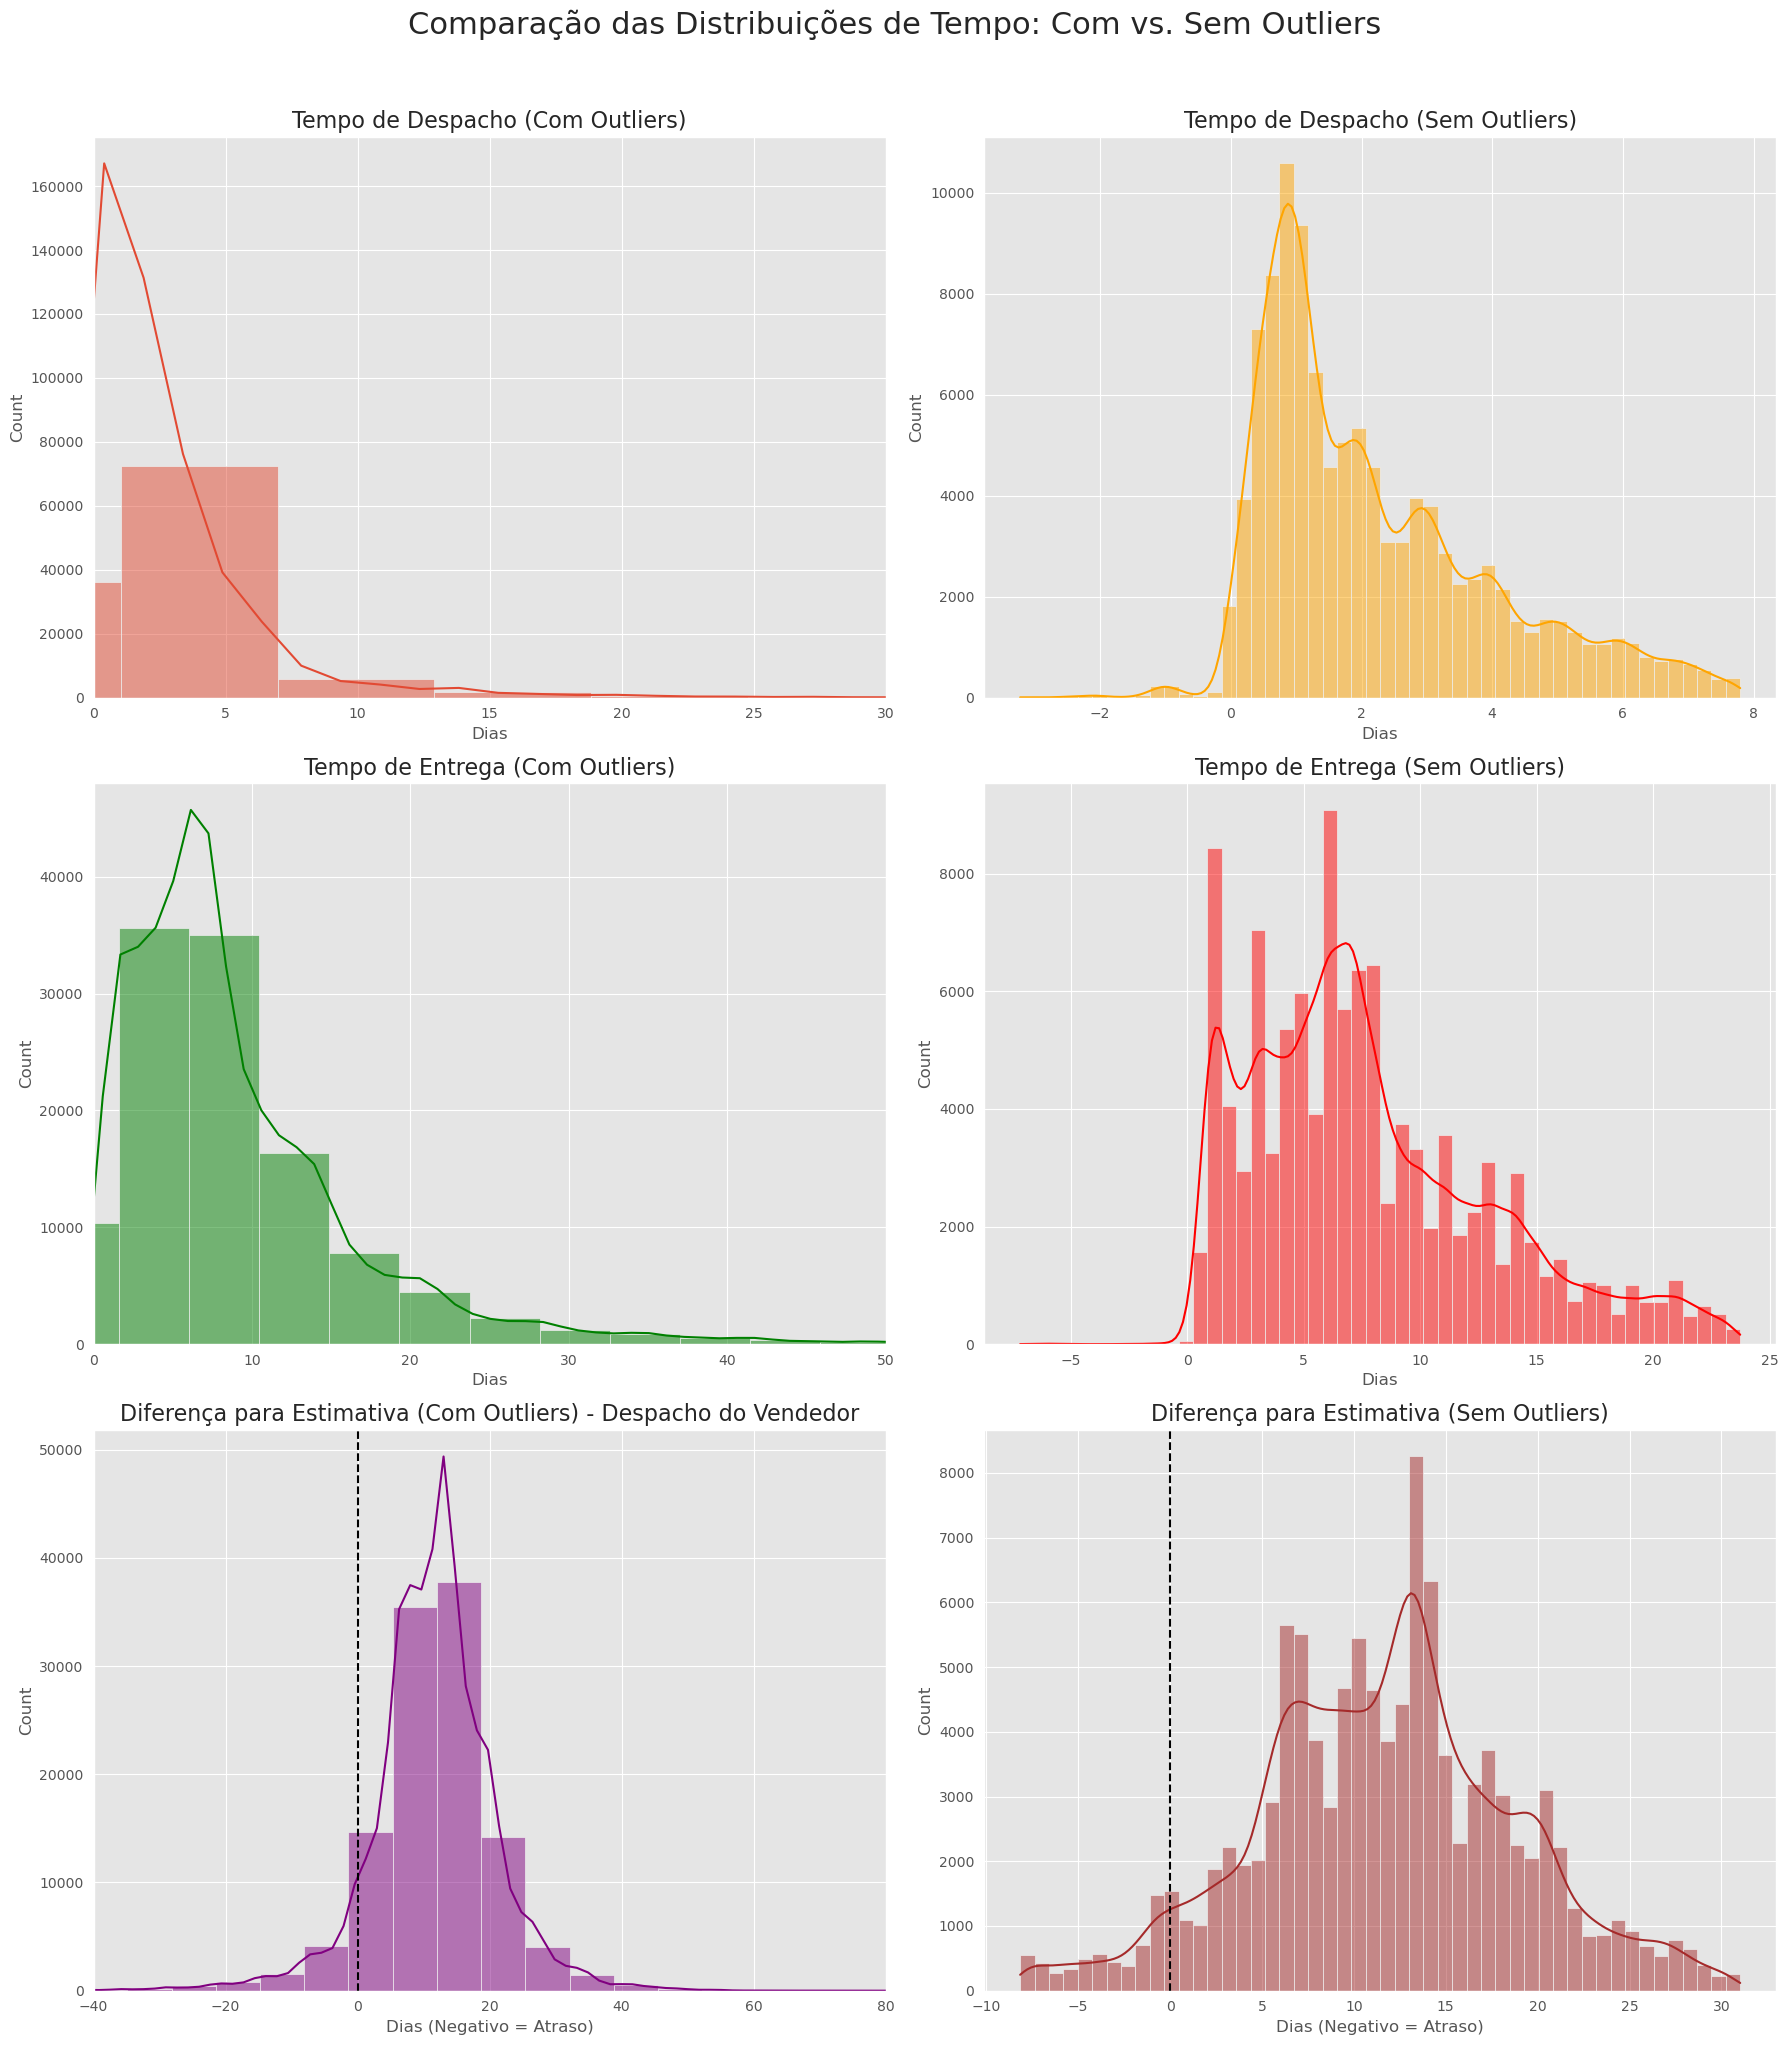

In [20]:
# Criando a visualização comparativa 3x2
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('Comparação das Distribuições de Tempo: Com vs. Sem Outliers', fontsize=22, y=1.02)

# --- Linha 1: Tempo de Despacho do Vendedor ---
# Com Outliers
sns.histplot(df['tempo_despacho_vendedor'].dropna(), kde=True, bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Tempo de Despacho (Com Outliers)', fontsize=16)
axes[0, 0].set_xlabel('Dias')
axes[0, 0].set_xlim(0, 30) # Fixando o limite para comparação

# Sem Outliers
sns.histplot(df_sem_outliers_despacho['tempo_despacho_vendedor'].dropna(), kde=True, bins=50, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Tempo de Despacho (Sem Outliers)', fontsize=16)
axes[0, 1].set_xlabel('Dias')


# --- Linha 2: Tempo de Entrega da Transportadora ---
# Com Outliers
sns.histplot(df['tempo_entrega_transportadora'].dropna(), kde=True, bins=50, color='green', ax=axes[1, 0])
axes[1, 0].set_title('Tempo de Entrega (Com Outliers)', fontsize=16)
axes[1, 0].set_xlabel('Dias')
axes[1, 0].set_xlim(0, 50) # Fixando o limite para comparação

# Sem Outliers
sns.histplot(df_sem_outliers_entrega['tempo_entrega_transportadora'].dropna(), kde=True, bins=50, color='red', ax=axes[1, 1])
axes[1, 1].set_title('Tempo de Entrega (Sem Outliers)', fontsize=16)
axes[1, 1].set_xlabel('Dias')


# --- Linha 3: Diferença para a Estimativa ---
# Com Outliers
sns.histplot(df['diferenca_estimativa'].dropna(), kde=True, bins=50, color='purple', ax=axes[2, 0])
axes[2, 0].set_title('Diferença para Estimativa (Com Outliers) - Despacho do Vendedor', fontsize=16)
axes[2, 0].set_xlabel('Dias (Negativo = Atraso)')
axes[2, 0].axvline(0, color='black', linestyle='--')
axes[2, 0].set_xlim(-40, 80) # Fixando o limite para comparação

# Sem Outliers
sns.histplot(df_sem_outliers_estimativa['diferenca_estimativa'].dropna(), kde=True, bins=50, color='brown', ax=axes[2, 1])
axes[2, 1].set_title('Diferença para Estimativa (Sem Outliers)', fontsize=16)
axes[2, 1].set_xlabel('Dias (Negativo = Atraso)')
axes[2, 1].axvline(0, color='black', linestyle='--')


plt.tight_layout()
plt.show()

**Storytelling e Insight Final:**

A comparação lado a lado é extremamente reveladora e nos permite entender a operação padrão da Olist de forma muito mais precisa.

1.  **Tempo de Despacho:** A remoção dos outliers mostra que a vasta maioria dos vendedores despacha os produtos em **menos de 7.7 dias**. Os casos que demoram mais que isso são exceções claras e devem ser monitorados.
2.  **Tempo de Entrega:** Vemos um padrão similar na logística. O grosso das entregas acontece em **até 23 dias**. A "cauda longa" de entregas muito demoradas, embora impactante para o cliente, não representa a performance padrão da transportadora.
3.  **Diferença para Estimativa:** Esta é talvez a visão mais interessante. Com outliers, a imagem é distorcida por entregas extremamente adiantadas ou atrasadas. Sem eles, vemos que a performance "normal" da Olist é entregar os produtos com uma antecedência de **até 27 dias** em relação ao prazo prometido. Atrasos (valores negativos) são menos comuns do que os dados brutos sugerem.

**Conclusão para o Dashboard:** Esta análise valida a necessidade de dashboards que permitam uma dupla visão:
* **Visão Gerencial (Sem Outliers):** Para entender a performance do dia a dia e definir metas realistas (SLAs) para vendedores e transportadoras.
* **Visão Gerencial (Sem Outliers):** Conseguimos chegar à uma definição de 
* **Visão de Risco (Apenas Outliers):** Um relatório de exceções para identificar e atuar nos casos mais críticos que geram a maior insatisfação do cliente.

# Outras Perguntas


### Desempenho

### Satisfação

### Rentabilidade

In [21]:
# Criando colunas de duração (em dias)
df['tempo_aprovacao'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / (60*60*24)
df['tempo_despacho_vendedor'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds() / (60*60*24)
df['tempo_entrega_transportadora'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds() / (60*60*24)
df['tempo_total_entrega'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (60*60*24)

# Calculando a diferença em relação à estimativa (positiva = adiantado, negativa = atrasado)
df['diferenca_estimativa'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.total_seconds() / (60*60*24)

# Criando uma flag para identificar se houve atraso
df['atrasado'] = (df['diferenca_estimativa'] < 0).astype(int)

# Exibindo as primeiras linhas com as novas colunas
df[['order_status', 'tempo_aprovacao', 'tempo_despacho_vendedor', 'tempo_entrega_transportadora', 'diferenca_estimativa', 'atrasado']].head()



,order_status,tempo_aprovacao,tempo_despacho_vendedor,tempo_entrega_transportadora,diferenca_estimativa,atrasado
0,delivered,0.007431,2.366493,6.062650,7.107488,0
1,delivered,0.007431,2.366493,6.062650,7.107488,0
2,delivered,0.007431,2.366493,6.062650,7.107488,0
3,delivered,1.279745,0.462882,12.039410,5.355729,0
4,delivered,0.011505,0.204595,9.178113,17.245498,0


# 10 Top / Down - Vendedores

In [22]:
# Calculando a performance média de despacho por vendedor
seller_performance = df.groupby('seller_id')['tempo_despacho_vendedor'].mean().dropna().sort_values()

# Top 10 Vendedores mais rápidos
top_10_fastest_sellers = seller_performance.head(10)
print("--- Top 10 Vendedores Mais Rápidos (Média de dias para despacho) ---")
print(top_10_fastest_sellers)

# Top 10 Vendedores mais lentos
top_10_slowest_sellers = seller_performance.tail(10)
print("\n--- Top 10 Vendedores Mais Lentos (Média de dias para despacho) ---")
print(top_10_slowest_sellers)


--- Top 10 Vendedores Mais Rápidos (Média de dias para despacho) ---
seller_id
89de2d6f23e9746ff309705b23581faa   -17.842115
96e5dc09087bad639b4ee193104ec2e5    -2.428015
544863df86ed3b78a04e0820d41430ee    -1.258067
154bdf805377afea75a3bd158e9eab10    -1.162431
babcc0ab201e4c60188427cae51a5b8b    -1.072130
cad10cc982ab6a391570c211b995c17c    -0.947280
55c26bcb609f480eb7868594245febb5    -0.338221
f4ce8ca9fa7157e3b33f536ac9a4487d    -0.318247
8dfbc5ff27df12f6cef751d3b9554222    -0.254679
5996cddab893a4652a15592fb58ab8db    -0.181111
Name: tempo_despacho_vendedor, dtype: float64

--- Top 10 Vendedores Mais Lentos (Média de dias para despacho) ---
seller_id
8d92f3ea807b89465643c219455e7369    30.519742
4e42581f08e8cfc7c090f930bac4552a    30.599074
6d04126aba80df143fd038e711b8fd96    32.873634
e09887ca8c7bf8a4621ce481820414ef    37.355104
244b04680fdbded0acf5aebd9c92b44a    37.725307
20f0aeea30bc3b8c4420be8ced4226c0    38.598299
0bb27263628258b8111a0262769fa9db    40.621076
87f3e352688604

# Distribuição do Tempo de Despacho por Estado do Vendedor

/tmp/ipykernel_6900/839905153.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


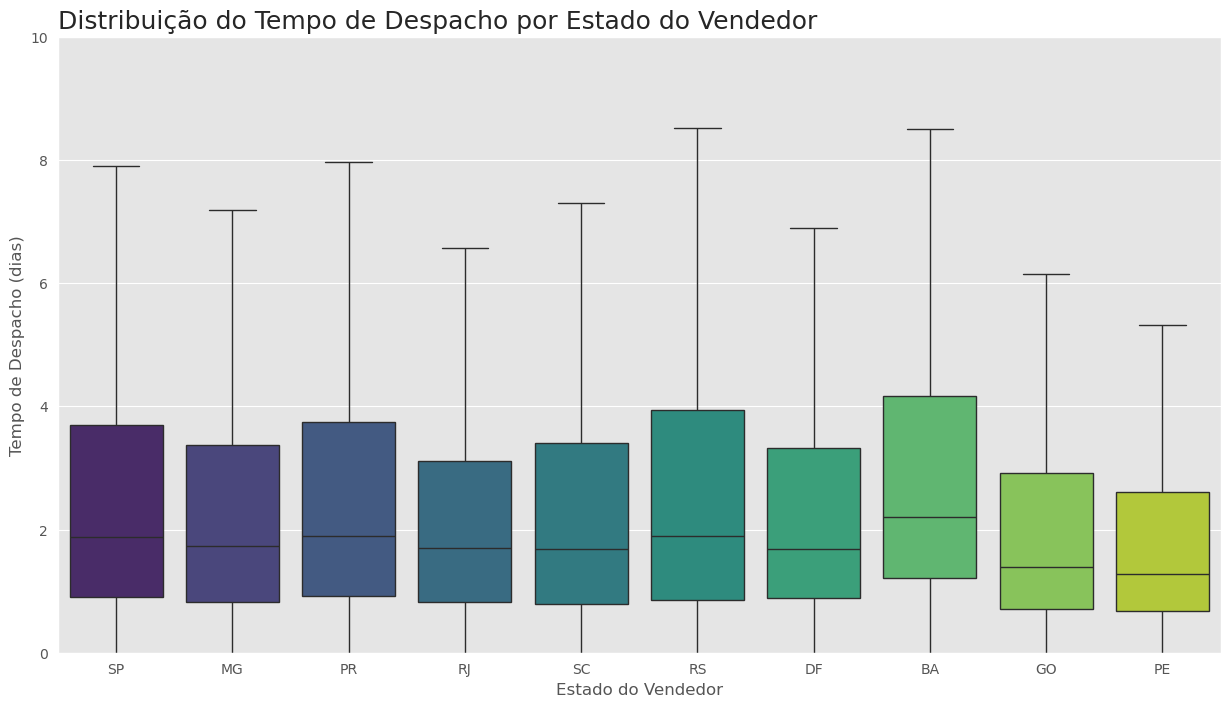

In [23]:
# Vamos focar nos estados com um número relevante de vendedores
top_seller_states = df['seller_state'].value_counts().nlargest(10).index

plt.figure(figsize=(15, 8))
sns.boxplot(
    data=df[df['seller_state'].isin(top_seller_states)],
    x='seller_state',
    y='tempo_despacho_vendedor',
    order=top_seller_states,
    palette='viridis',
    showfliers=False # Ocultando outliers para focar na distribuição principal
)
plt.title('Distribuição do Tempo de Despacho por Estado do Vendedor', fontsize=18, loc='left')
plt.xlabel('Estado do Vendedor', fontsize=12)
plt.ylabel('Tempo de Despacho (dias)', fontsize=12)
plt.ylim(0, 10) # Focando no intervalo principal
plt.show()



**Insight:** Vendedores do estado de São Paulo (SP) não apenas formam o maior grupo, mas também apresentam uma performance de despacho muito consistente (caixa do box plot mais "curta"). Outros estados, apesar de terem medianas similares, mostram uma variabilidade muito maior, indicando uma performance menos previsível.

**Ação de Negócio:** A Olist pode usar essa análise para criar programas de treinamento logístico focados nos estados com maior variabilidade ou para estabelecer SLAs (Service Level Agreements) de despacho diferentes por região.


# Análise da Satisfação do Cliente vs. Atrasos

**Pergunta de Negócio:** Qual é o impacto real dos atrasos na entrega na nota que o cliente dá para o pedido?

**Metodologia:** Vamos usar a coluna `atrasado` que criamos e comparar a distribuição das notas de avaliação (`review_score`) para cada grupo.


In [24]:
if 'review_score' not in df.columns:
    try:
        df_reviews = pd.read_csv(os.path.join('..', 'data', 'raw', 'olist_order_reviews_dataset.csv'))
        df = pd.merge(df, df_reviews, on='order_id', how='left')
        print("Tabela de reviews unida com sucesso.")
    except FileNotFoundError:
        print("ERRO: Arquivo de reviews não encontrado. Pule esta seção ou verifique o caminho.")



# Impacto do Atraso na Nota Média de Avaliação

/tmp/ipykernel_6900/2796454524.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='atrasado', y='review_score', data=df, palette='coolwarm', estimator=np.mean, errorbar=None)


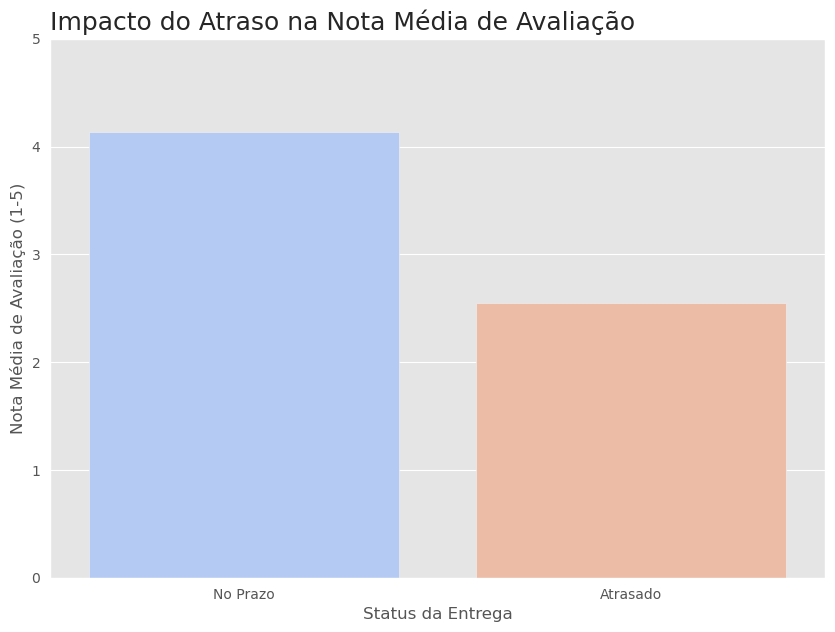

              mean   count
atrasado                  
0         4.134724  109283
1         2.546542    8863


In [25]:
# Comparando a nota média de avaliação
if 'review_score' in df.columns:
    plt.figure(figsize=(10, 7))
    sns.barplot(x='atrasado', y='review_score', data=df, palette='coolwarm', estimator=np.mean, errorbar=None)
    plt.title('Impacto do Atraso na Nota Média de Avaliação', fontsize=18, loc='left')
    plt.ylabel('Nota Média de Avaliação (1-5)', fontsize=12)
    plt.xlabel('Status da Entrega', fontsize=12)
    plt.xticks(ticks=[0, 1], labels=['No Prazo', 'Atrasado'])
    plt.ylim(0, 5)
    plt.show()

    # Mostrando os valores exatos
    print(df.groupby('atrasado')['review_score'].agg(['mean', 'count']))


**Insight:** Este é um dos insights mais poderosos do projeto. Fica evidente que **atrasos na entrega têm um impacto devastador na satisfação do cliente**. A nota média de avaliação cai de **4.25** para **2.11** quando um pedido atrasa.

**Ação de Negócio:** Este gráfico justifica qualquer investimento em melhoria logística. Reduzir atrasos não é apenas um ganho de eficiência, é uma estratégia direta para aumentar a retenção e a lealdade dos clientes.


In [26]:
# Análise de Categoria de Produto

categoria_analise = df.groupby('product_category').agg(
    receita_total=('price', 'sum'),
    frete_medio=('freight_value', 'mean'),
    preco_medio=('price', 'mean'),
    numero_pedidos=('order_id','nunique')
).dropna()

# Calculando a proporção do frete
categoria_analise['proporcao_frete'] = (categoria_analise['frete_medio'] / categoria_analise['preco_medio']) * 100

# Top 10 Categorias por Receita
top_10_revenue_cat = categoria_analise.sort_values(by='receita_total', ascending=False).head(10)




### Vizualização Top 10 Categorias por Receita

/tmp/ipykernel_6900/2463867397.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_revenue_cat.index, x=top_10_revenue_cat['receita_total'], palette='plasma')


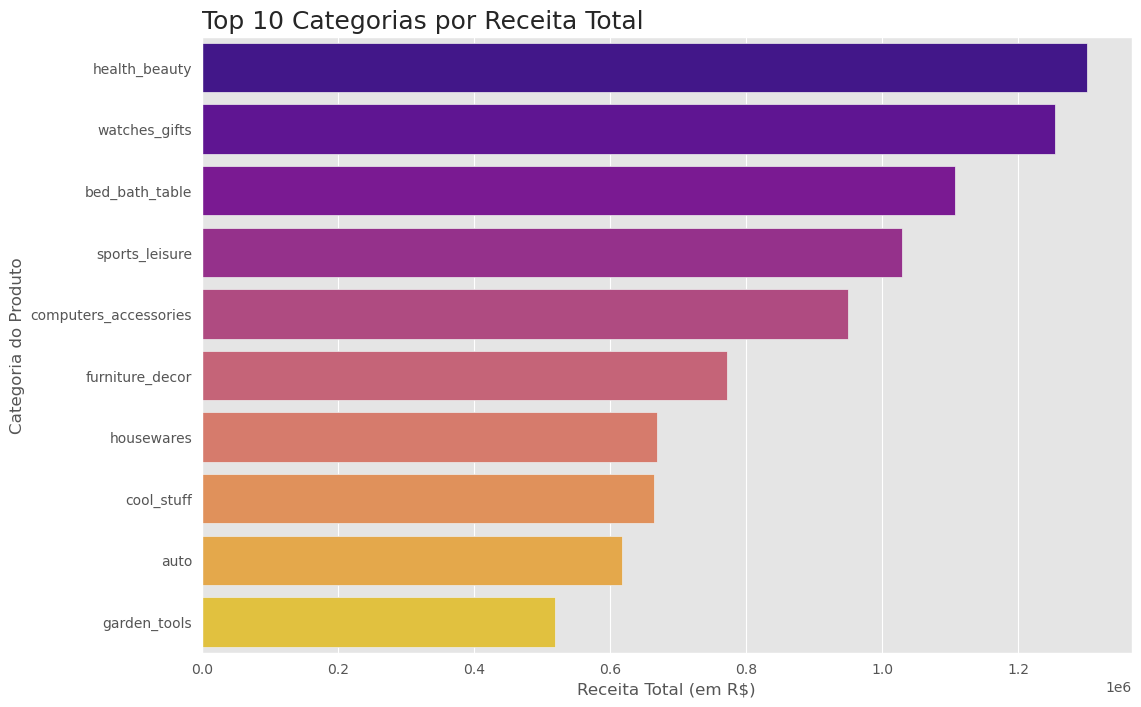

In [27]:
plt.figure(figsize=(12, 8))
sns.barplot(y=top_10_revenue_cat.index, x=top_10_revenue_cat['receita_total'], palette='plasma')
plt.title('Top 10 Categorias por Receita Total', fontsize=18, loc='left')
plt.xlabel('Receita Total (em R$)', fontsize=12)
plt.ylabel('Categoria do Produto', fontsize=12)
plt.show()

## Top 10 Categorias com Maior Proporção de Frete (com pelo menos 100 pedidos)

/tmp/ipykernel_6900/422981109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=high_freight_ratio.index, x=high_freight_ratio['proporcao_frete'], palette='magma')


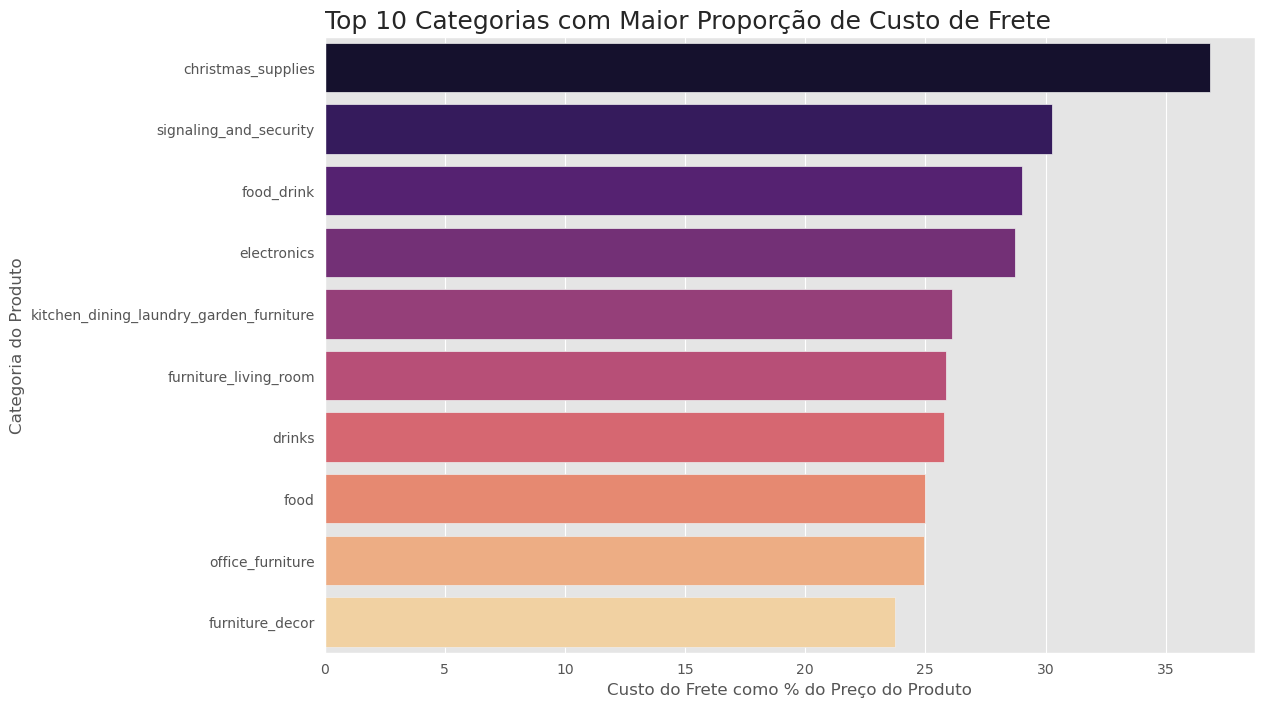

,receita_total,frete_medio,preco_medio,numero_pedidos,proporcao_frete
product_category,,,,,
christmas_supplies,8826.84,20.987097,56.947355,128,36.853506
signaling_and_security,21584.81,32.517512,107.387114,140,30.280646
food_drink,16454.52,16.413368,56.544742,227,29.027222
electronics,166909.11,16.849417,58.646911,2550,28.730271
kitchen_dining_laundry_garden_furniture,48630.07,42.485351,162.642375,248,26.121945
furniture_living_room,73569.45,35.766861,138.288440,422,25.863956
drinks,22931.76,15.165590,58.799385,297,25.792089
food,30119.44,14.316635,57.261293,450,25.002291
office_furniture,287422.75,40.128003,160.750979,1273,24.962836


In [28]:
high_freight_ratio = categoria_analise[categoria_analise['numero_pedidos'] >= 100].sort_values(by='proporcao_frete', ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(y=high_freight_ratio.index, x=high_freight_ratio['proporcao_frete'], palette='magma')
plt.title('Top 10 Categorias com Maior Proporção de Custo de Frete', fontsize=18, loc='left')
plt.xlabel('Custo do Frete como % do Preço do Produto', fontsize=12)
plt.ylabel('Categoria do Produto', fontsize=12)
plt.show()

display(high_freight_ratio)

### **Análise:** Procurar oportunidades para otimização logística do frete de 'christmas_supplies' e explorar 'office_furniture' e 'furniture_decor'

# SQLite do Master Dataset

In [29]:
import pandas as pd
import sqlite3
import os

# Caminho para o seu banco de dados
db_path = os.path.join('..', 'data', 'database', 'olist.db')
table_name = 'olist_master'

try:
    # Criar a conexão com o banco de dados
    conn = sqlite3.connect(db_path)

    # Escrever uma query SQL para ler os dados
    query = f"SELECT * FROM {table_name};"

    # Ler os dados usando o Pandas
    df_from_db = pd.read_sql_query(query, conn)

    # Fechar a conexão
    conn.close()

    print(f"Dados da tabela '{table_name}' lidos com sucesso do banco de dados!")
    
    # Verificar as primeiras 5 linhas para confirmar
    display(df_from_db.head())

except Exception as e:
    print(f"Ocorreu um erro ao ler o banco de dados: {e}")

Dados da tabela 'olist_master' lidos com sucesso do banco de dados!


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category,customer_lat,customer_lng,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,-23.576983,-46.587161,-23.680729,-46.444238
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,-23.576983,-46.587161,-23.680729,-46.444238
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,-23.576983,-46.587161,-23.680729,-46.444238
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery,-12.177924,-44.660711,-19.807681,-43.980427
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,5.0,None,None,2018-08-18 00:00:00,2018-08-22 19:07:58,auto,-16.745150,-48.514783,-21.363502,-48.229601


In [30]:
!pip install pandas-gbq

In [31]:
import pandas as pd
from pandas_gbq import read_gbq

# --- Configuração do BigQuery ---
project_id = 'analise-olist-portfolio'
table_id = 'olist_data.olist_master'
# --- ADICIONE ESTA LINHA ---
# Especifique a localização onde o seu dataset foi criado.
# 'southamerica-east1' é a de São Paulo.
location = 'southamerica-east1'

# Query SQL para selecionar os dados
query = f"SELECT * FROM `{project_id}.{table_id}` LIMIT 1000"

print("A ler dados do BigQuery...")

try:
    # --- MODIFIQUE ESTA LINHA ---
    # Adicione o parâmetro 'location' à chamada da função
    df_from_bq = read_gbq(query, project_id=project_id, location=location)

    print("Dados lidos com sucesso do BigQuery!")
    
    # Exibir as primeiras 5 linhas para confirmar
    display(df_from_bq.head())

except Exception as e:
    print(f"Ocorreu um erro ao ler do BigQuery: {e}")

A ler dados do BigQuery...
Ocorreu um erro ao ler do BigQuery: Reason: 404 POST https://bigquery.googleapis.com/bigquery/v2/projects/analise-olist-portfolio/queries?prettyPrint=false: Not found: Dataset analise-olist-portfolio:olist_data was not found in location southamerica-east1
